In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
patient_df = pd.read_csv('./skin-cancer-mnist-ham10000/versions/2/HAM10000_metadata.csv')

In [3]:
patient_df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [4]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
patient_df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [6]:
patient_df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [7]:
patient_df.duplicated().sum()

0

In [8]:
patient_df['age'] = patient_df['age'].fillna(patient_df['age'].mean())

In [9]:
patient_df.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [10]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [11]:
patient_df['cell_type'] = patient_df['dx'].map(lesion_type_dict)
patient_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions


In [12]:
patient_df['age'].value_counts()

age
45.000000    1299
50.000000    1187
55.000000    1009
40.000000     985
60.000000     803
70.000000     756
35.000000     753
65.000000     731
75.000000     618
30.000000     464
80.000000     404
85.000000     290
25.000000     247
20.000000     169
5.000000       86
15.000000      77
51.863828      57
10.000000      41
0.000000       39
Name: count, dtype: int64

In [13]:
patient_df = patient_df[patient_df['age']!=0]

In [14]:
patient_df['sex'].value_counts()

sex
male       5383
female     4538
unknown      55
Name: count, dtype: int64

In [15]:
patient_df = patient_df[patient_df['sex']!='unknown']

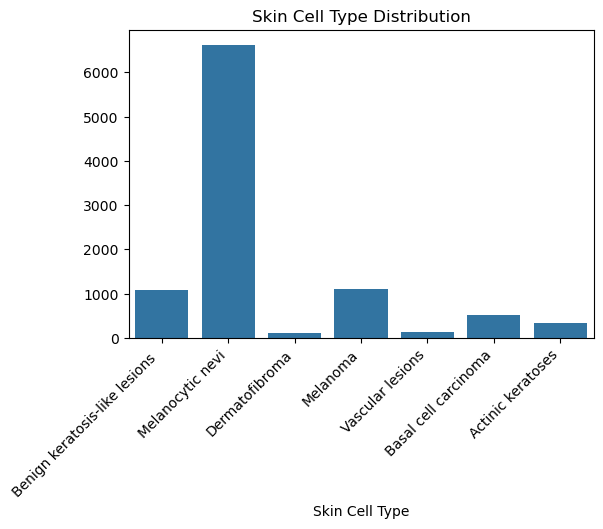

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Cell Type Distribution')
plt.xlabel('Skin Cell Type')
plt.ylabel('')
plt.show()

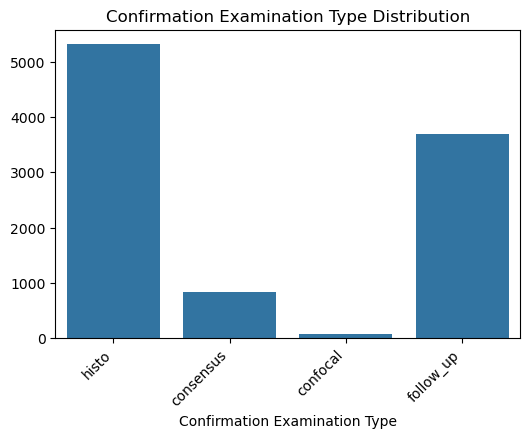

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='dx_type')
plt.xticks(rotation=45,ha='right')
plt.title('Confirmation Examination Type Distribution')
plt.xlabel('Confirmation Examination Type')
plt.ylabel('')
plt.show()

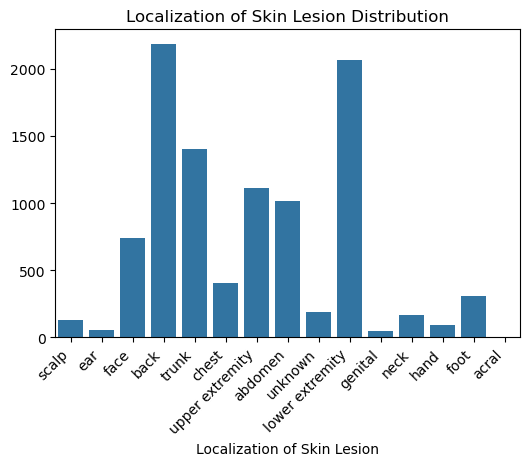

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='localization')
plt.xticks(rotation=45,ha='right')
plt.title('Localization of Skin Lesion Distribution')
plt.xlabel('Localization of Skin Lesion')
plt.ylabel('')
plt.show()

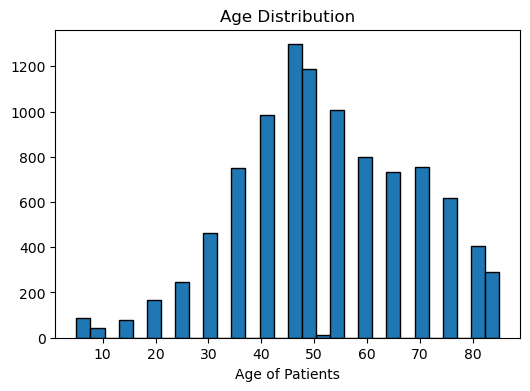

In [19]:
plt.figure(figsize=(6,4))
plt.hist(x=patient_df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age of Patients')
plt.ylabel('')
plt.show()

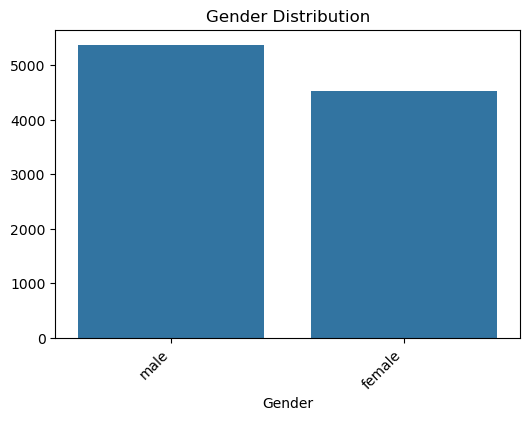

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='sex')
plt.xticks(rotation=45,ha='right')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('')
plt.show()